In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [5]:
# Overall Churn
# df["Churn"].value_counts()
# First calculate the number of customers in each category:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


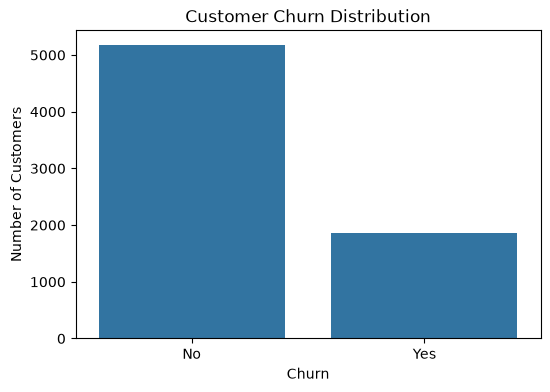

In [6]:
# Churn Visualization
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
# Churn by Contract Type
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


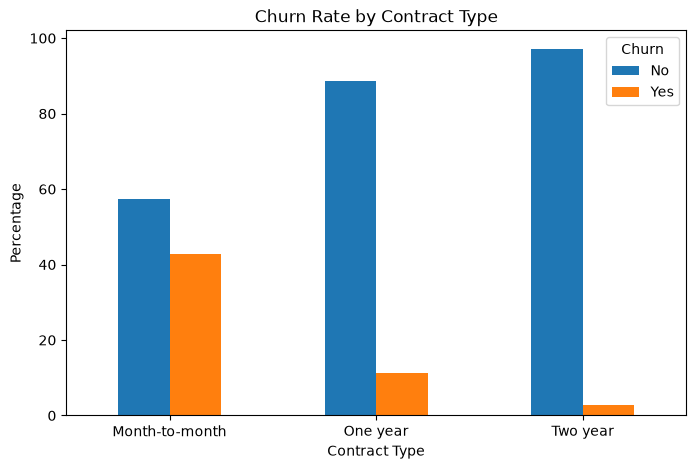

In [ ]:
# Visualize
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

# Month-to-month → highest churn
# One year       → lower churn
# Two year       → lowest churn

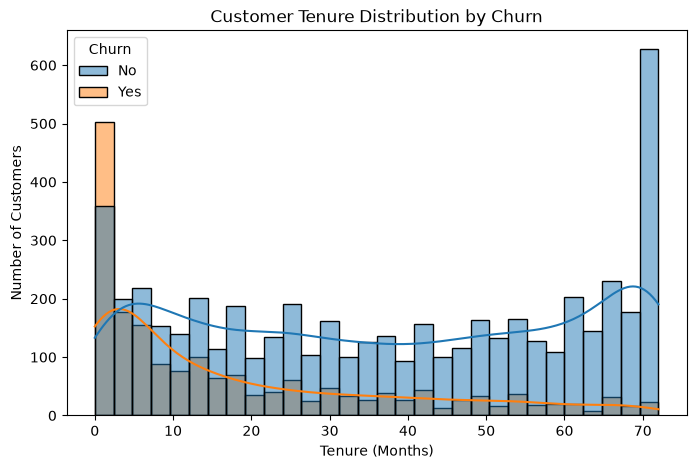

In [9]:
# Churn by Tenure
# Tenure means:
# How long the customer has been with the company.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
# Then create tenure groups:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [ ]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

# This helps us identify whether new customers are more likely to leave.

Churn                No        Yes
TenureGroup                       
0-12 Months   52.321839  47.678161
13-24 Months  71.289062  28.710938
25-48 Months  79.611041  20.388959
49-72 Months  90.486824   9.513176


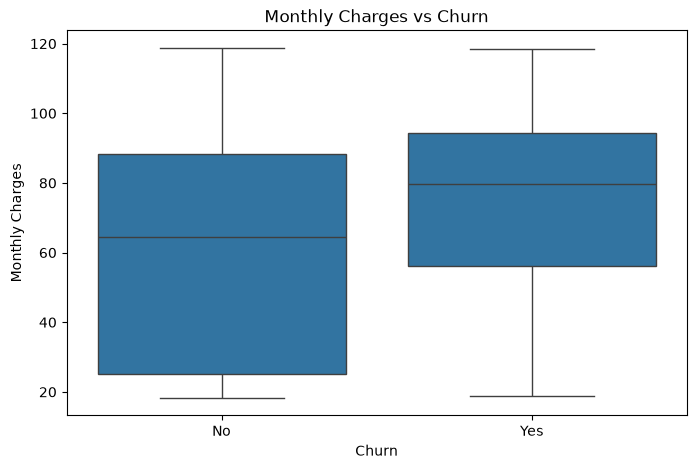

In [12]:
# Churn vs Monthly Charges
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [13]:
# Churn by Internet Service
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


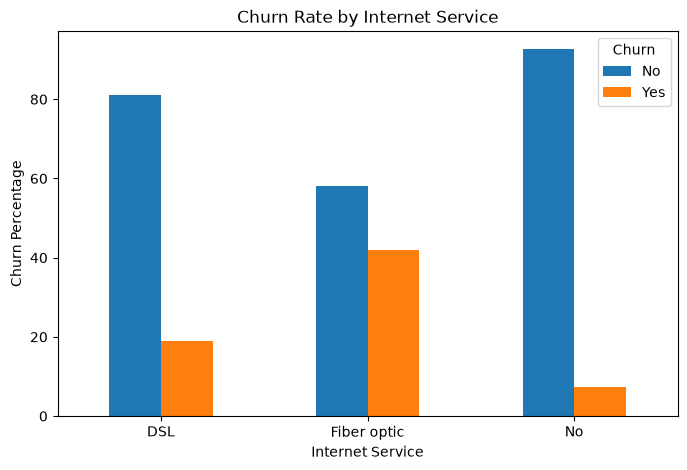

In [14]:
# Visualize
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.show()

In [15]:
# Churn by Payment Method
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


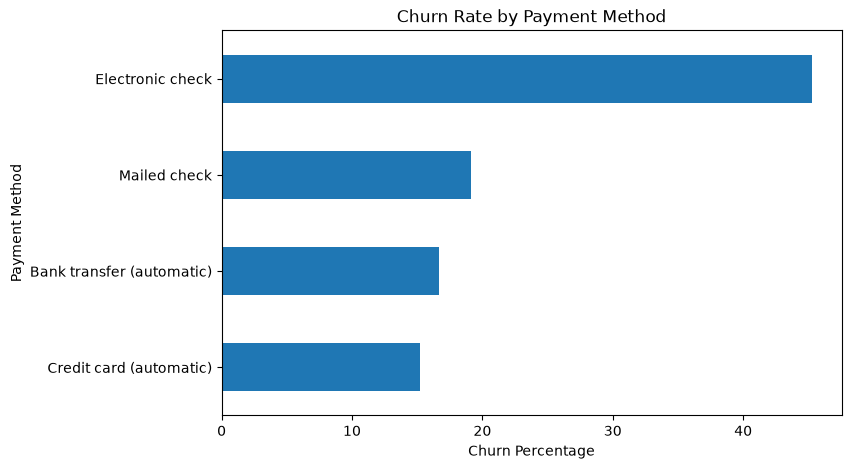

In [ ]:
# This can reveal which payment methods are associated with higher churn.(plot)
payment_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Percentage")
plt.ylabel("Payment Method")

plt.show()

In [17]:
# Churn by Senior Citizen
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [18]:
# For better labels
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

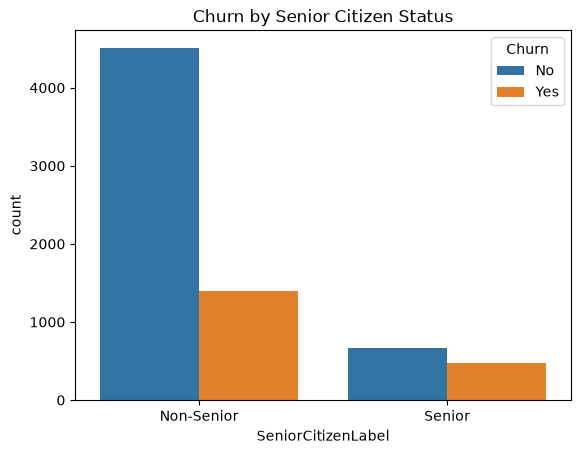

In [19]:
sns.countplot(
    data=df,
    x="SeniorCitizenLabel",
    hue="Churn"
)

plt.title("Churn by Senior Citizen Status")
plt.show()

In [20]:
# Churn by Tech Support
# This is useful from a business perspective.
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(tech_support_churn)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


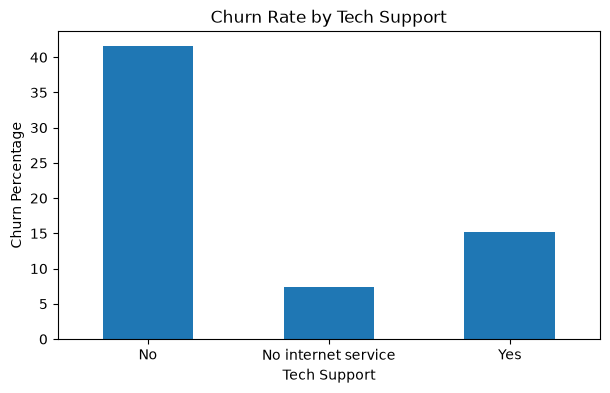

In [21]:
tech_support_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.show()

In [22]:
# Correlation Analysis
numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation = df[numeric_columns].corr()

print(correlation)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.103006
tenure               0.016567  1.000000        0.247900      0.826178
MonthlyCharges       0.220173  0.247900        1.000000      0.651174
TotalCharges         0.103006  0.826178        0.651174      1.000000


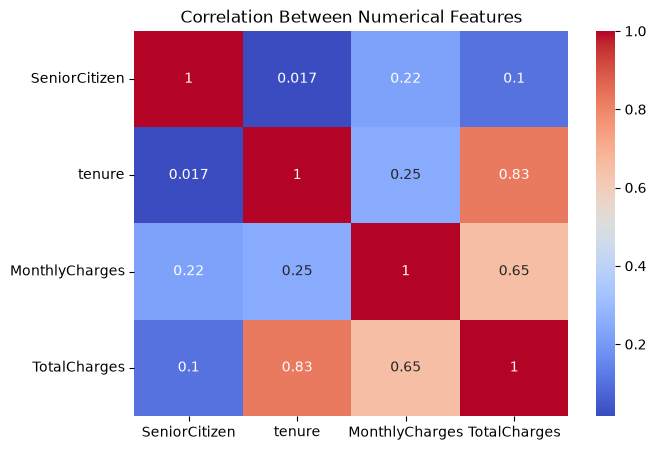

In [23]:
# HeatMap
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")

plt.show()

In [ ]:
### Key EDA Findings

# 1. The overall customer churn rate is approximately 26.54%.

# 2. Month-to-month contract customers have the highest churn rate,
#    at approximately 43%.

# 3. Customers with one-year and two-year contracts have substantially
#    lower churn rates.

# 4. Customers with shorter tenure are more likely to churn.
#    The highest churn is observed among customers with less than
#    one year of tenure.

# 5. Churned customers generally have higher monthly charges than
#    customers who remain with the company.

# 6. Contract type, customer tenure, and monthly charges appear to be
#    important factors associated with customer churn.

Next: Customer Services Analysis

Now let's investigate whether additional services are associated with customer retention.
We'll analyze:
    1)Online Security
    2)Online Backup
    3)Device Protection
    4)Streaming TV
    5)Streaming Movies

In [24]:
# Analyze all service features
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies"
]

for column in service_columns:
    print(f"\n===== {column} =====")

    result = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print(result)


===== OnlineSecurity =====
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

===== OnlineBackup =====
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

===== DeviceProtection =====
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

===== StreamingTV =====
Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188

===== StreamingMovies =====
Churn                 

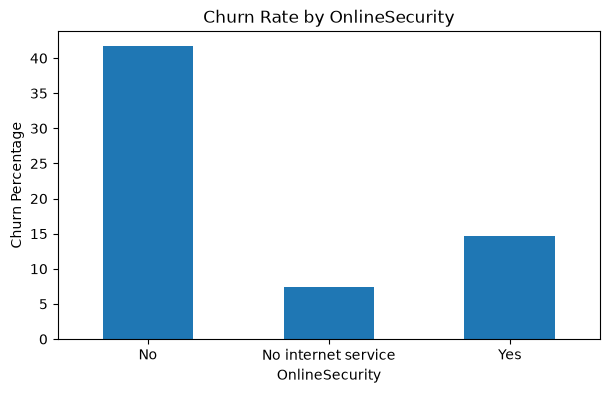

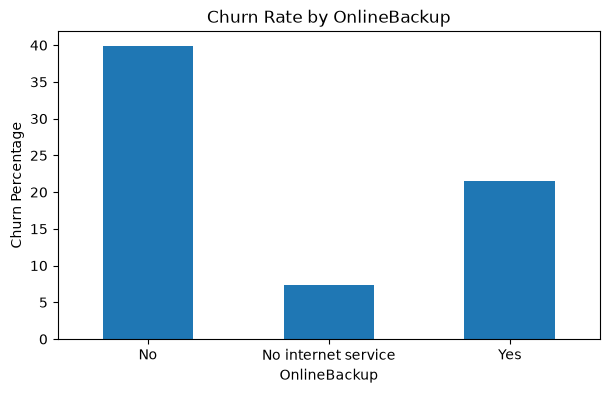

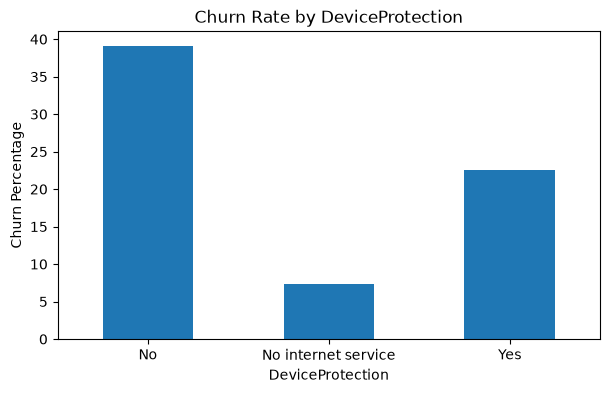

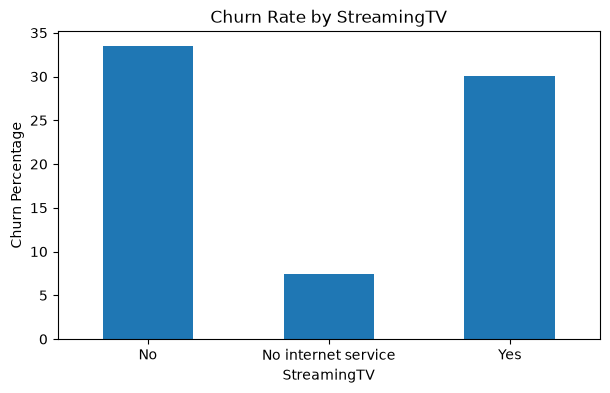

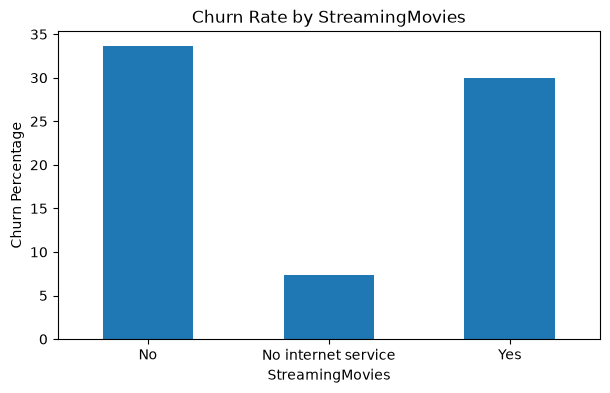

In [ ]:
# Visualize service analysis 
for column in service_columns:

    churn_rate = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    churn_rate["Yes"].plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn Percentage")
    plt.xticks(rotation=0)
    plt.show()

In [26]:
# Partner and Dependents
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn)

Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


In [27]:
# Dependents
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print(dependents_churn)

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


In [28]:
# Paperless Billing
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

print(paperless_churn)

Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092


In [29]:
# Gender
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn)

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


In [31]:
# Create a Feature Summary
summary = pd.DataFrame({
    "Feature": [
        "Contract",
        "InternetService",
        "PaymentMethod",
        "TechSupport",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "PaperlessBilling",
        "Partner",
        "Dependents"
    ],
    "Analysis": [
        "Month-to-month customers have the highest churn",
        "Fiber optic customers have higher churn",
        "Electronic check has the highest churn",
        "Customers without tech support have higher churn",
        "Customers without online security have higher churn",
        "Customers without online backup have higher churn",
        "Customers without device protection have higher churn",
        "Paperless billing is associated with higher churn",
        "Customers without partners have higher churn",
        "Customers without dependents have higher churn"
    ]
})

summary

,Feature,Analysis
0,Contract,Month-to-month customers have the highest churn
1,InternetService,Fiber optic customers have higher churn
2,PaymentMethod,Electronic check has the highest churn
3,TechSupport,Customers without tech support have higher churn
4,OnlineSecurity,Customers without online security have higher ...
5,OnlineBackup,Customers without online backup have higher churn
6,DeviceProtection,Customers without device protection have highe...
7,PaperlessBilling,Paperless billing is associated with higher churn
8,Partner,Customers without partners have higher churn
9,Dependents,Customers without dependents have higher churn
